In [ ]:
from pagerank.power_iteration import recursive_pagerank
from pagerank.eigendecomposition import matrix_pagerank, eigenvector_pagerank
from pagerank.utils import *

def plot_ranking(web,ranking,d=0.85):
    """
    plots a  representation of the input web, indicating 
    hyperlinks with lines, and visualizing the pagerank of each page
    by size.
    """
    import matplotlib.pyplot as plt
    import networkx as nx
    # 1. Create a Directed Graph object
    G = nx.DiGraph()
    
    # 2. Add edges from  web
    for source, targets in web.items():
        for target in targets:
            G.add_edge(source, target)
            
    # Sinks are also in the graph
    G.add_nodes_from(web.keys())

    node_list = list(G.nodes())
    color_map = []

    # Add colors
    for node in node_list:
        if ranking.get(node, 0) < 0.1:
            color_map.append('yellowgreen')
        elif ranking.get(node, 0) < 0.15:
            color_map.append('khaki')
        else:
            color_map.append('crimson')


    # Create labels for the nodes
    labels = {}
    for node in node_list:
        # print("node", ranking.get(node, 0))
        percentage = ranking.get(node, 0) * 100
        labels[node] = f"{node}\n{percentage:.1f}%"

        # if ranking.get(node, 0) < 0.5:
        #     color_map.append('indianred')
        # else:
        #     color_map.append('palevioletred')

    # Set up the layout
    pos = nx.spring_layout(G, k=0.8, iterations=25, scale=10)
    # Node sizes
    node_sizes = [ranking.get(node, 0) * 50000 for node in G.nodes()]
    # draw graph
    plt.figure(figsize=(12, 10))
    
    # draw nodes
    nx.draw_networkx_nodes(G, pos, 
                           node_size=node_sizes, 
                           node_color=color_map, # palevioletred
                           alpha=0.9)
    
    # draw edges with arrows
    nx.draw_networkx_edges(G, pos, 
                           arrowstyle='->', 
                           arrowsize=20, 
                           edge_color='lightgray', 
                           alpha=0.5, 
                           width=1.5)

    # draw the custom labels
    nx.draw_networkx_labels(G, pos, 
                            labels=labels, 
                            font_size=10, 
                            font_family='sans-serif',
                            font_weight='regular')

    plt.title("Network Visualization (Node size = PageRank)", fontsize=15)
    plt.axis('off')
    plt.show()

Total runtime of the eigenvector is 0.0014078617095947266 seconds


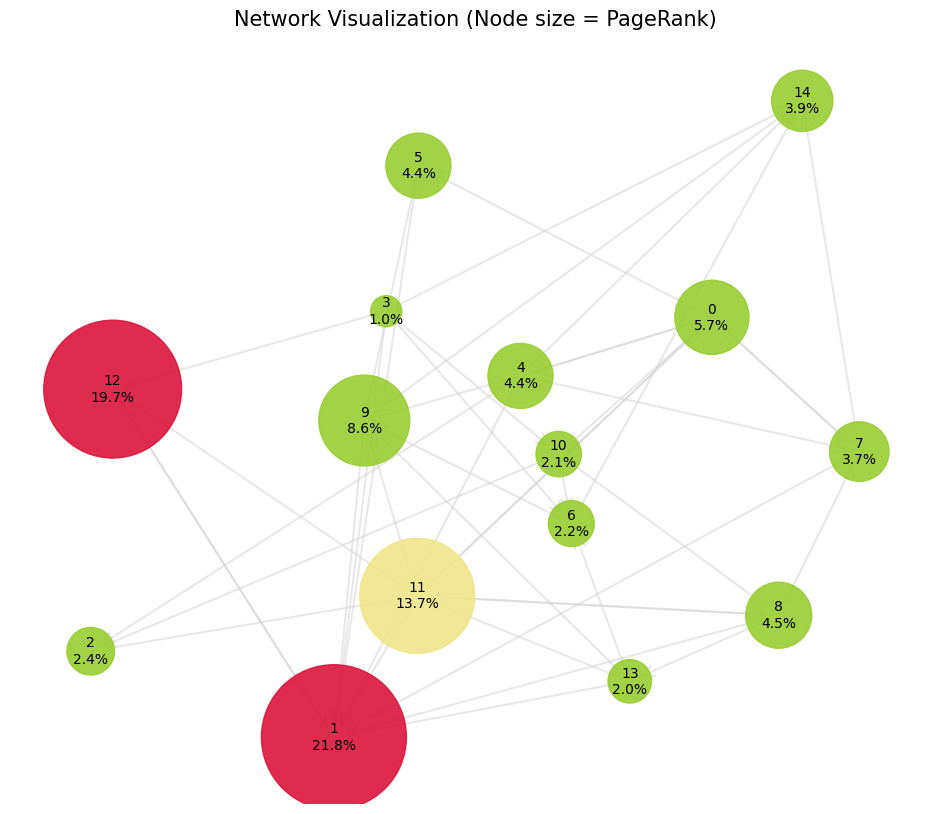

In [29]:
web3 = make_web(15,5)
ranking = eigenvector_pagerank(web3)
plot_ranking(web3, ranking)